In [1]:
# Day 5: Core Funnel SQL Analysis
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

In [2]:

load_dotenv('../.env')
engine = create_engine(os.getenv('DATABASE_URL'))
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Connected to warehouse")


✅ Connected to warehouse


In [3]:
# ===== QUERY 1: OVERALL FUNNEL =====
query_overall = """
WITH user_journey AS (
    SELECT 
        user_id,
        MAX(CASE WHEN event_type = 'page_view' THEN 1 ELSE 0 END) AS viewed,
        MAX(CASE WHEN event_type = 'product_view' THEN 1 ELSE 0 END) AS product_viewed,
        MAX(CASE WHEN event_type = 'add_to_cart' THEN 1 ELSE 0 END) AS carted,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchased
    FROM fact_events
    GROUP BY user_id
)
SELECT 
    SUM(viewed) AS page_views,
    SUM(product_viewed) AS product_views,
    SUM(carted) AS add_to_carts,
    SUM(purchased) AS purchases,
    ROUND(100.0 * SUM(product_viewed) / NULLIF(SUM(viewed), 0), 2) AS view_to_product_pct,
    ROUND(100.0 * SUM(carted) / NULLIF(SUM(product_viewed), 0), 2) AS product_to_cart_pct,
    ROUND(100.0 * SUM(purchased) / NULLIF(SUM(carted), 0), 2) AS cart_to_purchase_pct,
    ROUND(100.0 * SUM(purchased) / NULLIF(SUM(viewed), 0), 2) AS overall_conversion
FROM user_journey;
"""

overall = pd.read_sql(query_overall, engine)
print("\n📊 OVERALL FUNNEL:")
print(overall.T)



📊 OVERALL FUNNEL:
                            0
page_views            4870.00
product_views         4806.00
add_to_carts          1865.00
purchases              905.00
view_to_product_pct     98.69
product_to_cart_pct     38.81
cart_to_purchase_pct    48.53
overall_conversion      18.58


In [4]:
# ===== QUERY 2: FUNNEL BY HOUR =====
query_hour = """
SELECT 
    EXTRACT(HOUR FROM timestamp) AS hour,
    COUNT(DISTINCT CASE WHEN event_type = 'page_view' THEN user_id END) AS viewers,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS buyers,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) 
          / NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'page_view' THEN user_id END), 0), 2) AS conversion_rate
FROM fact_events
GROUP BY EXTRACT(HOUR FROM timestamp)
ORDER BY hour;
"""
by_hour = pd.read_sql(query_hour, engine)
print(f"\n📊 FUNNEL BY HOUR: {len(by_hour)} hours analyzed")



📊 FUNNEL BY HOUR: 24 hours analyzed


In [5]:
# ===== QUERY 3: FUNNEL BY YEAR (2024 vs 2025) =====
query_year = """
WITH user_journey AS (
    SELECT 
        EXTRACT(YEAR FROM timestamp) AS year,
        user_id,
        MAX(CASE WHEN event_type = 'page_view' THEN 1 ELSE 0 END) AS viewed,
        MAX(CASE WHEN event_type = 'add_to_cart' THEN 1 ELSE 0 END) AS carted,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchased
    FROM fact_events
    GROUP BY EXTRACT(YEAR FROM timestamp), user_id
)
SELECT 
    year,
    SUM(viewed) AS viewers,
    SUM(carted) AS cart_adders,
    SUM(purchased) AS buyers,
    ROUND(100.0 * SUM(purchased) / NULLIF(SUM(viewed), 0), 2) AS conversion_rate
FROM user_journey
GROUP BY year
ORDER BY year;
"""
by_year = pd.read_sql(query_year, engine)
print("\n📊 FUNNEL BY YEAR:")
print(by_year)



📊 FUNNEL BY YEAR:
     year  viewers  cart_adders  buyers  conversion_rate
0  2025.0     4870         1865     905            18.58


In [6]:
# ===== QUERY 4: TOP PRODUCTS =====
query_products = """
SELECT 
    product_id,
    COUNT(*) AS total_events,
    COUNT(CASE WHEN event_type = 'purchase' THEN 1 END) AS purchases,
    ROUND(SUM(CASE WHEN event_type = 'purchase' THEN amount ELSE 0 END)::numeric, 2) AS revenue
FROM fact_events
WHERE product_id IS NOT NULL
GROUP BY product_id
ORDER BY revenue DESC NULLS LAST
LIMIT 10;
"""
top_products = pd.read_sql(query_products, engine)
print(f"\n📊 TOP 10 PRODUCTS BY REVENUE:")
print(top_products)



📊 TOP 10 PRODUCTS BY REVENUE:
  product_id  total_events  purchases  revenue
0  prod_5183             8          2   909.74
1  prod_7553             8          2   862.62
2  prod_2398             7          2   822.10
3  prod_6879             9          2   818.40
4  prod_9739             8          2   803.91
5  prod_3915             8          2   797.11
6  prod_7633            10          2   794.30
7  prod_4529            11          3   790.57
8  prod_9882             5          2   785.03
9  prod_4044             9          2   782.95


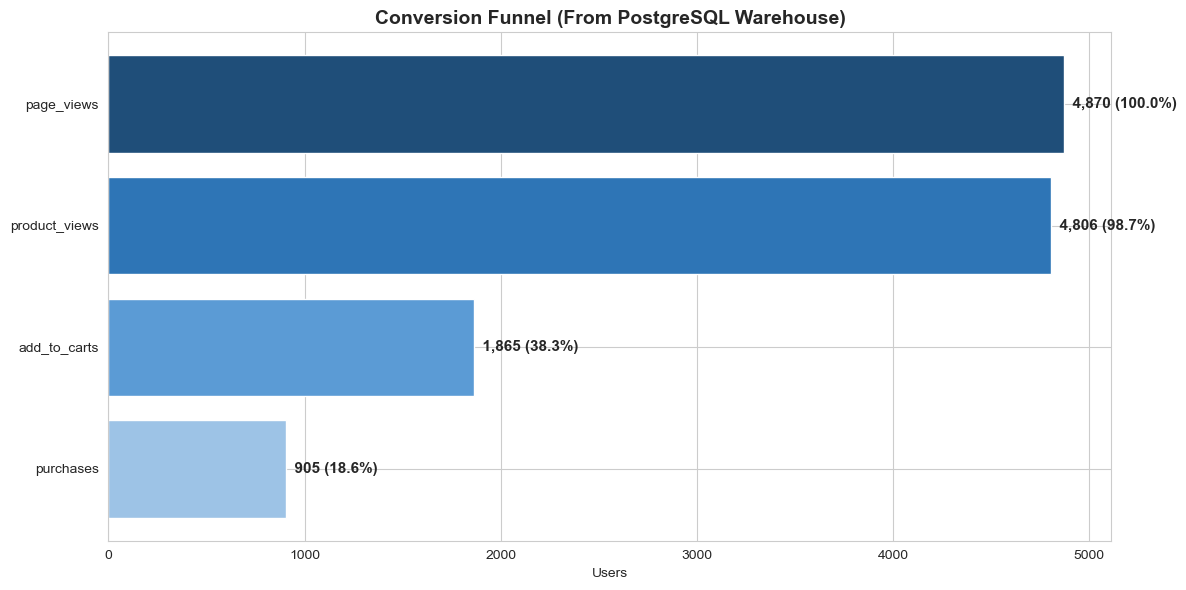

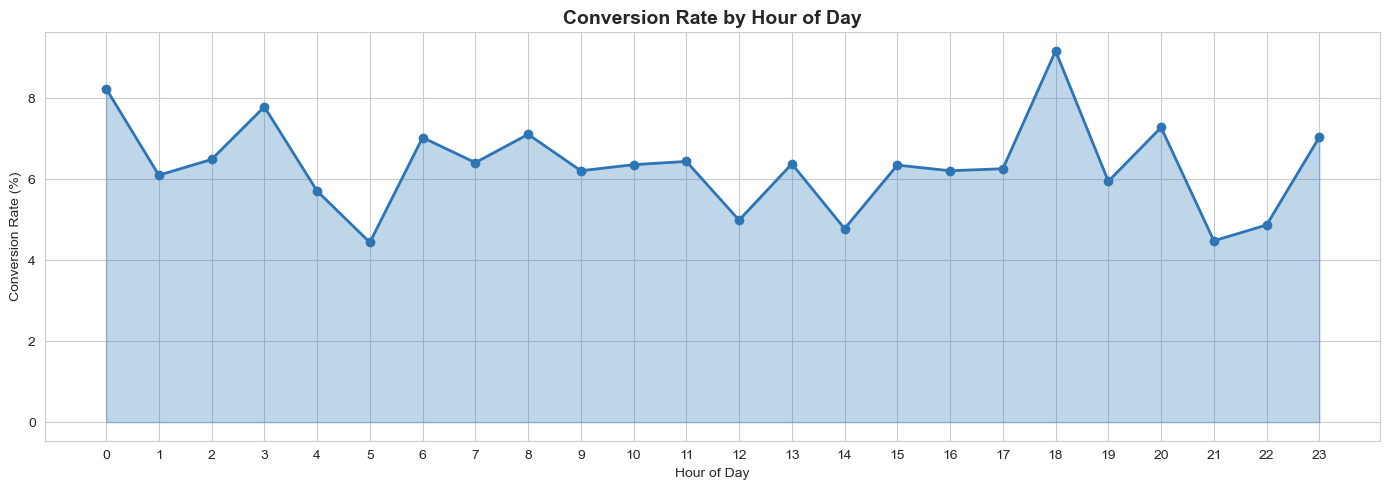

In [7]:


# ===== VISUALIZE FUNNEL =====
stages = ['page_views', 'product_views', 'add_to_carts', 'purchases']
values = [overall[s].iloc[0] for s in stages]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#1F4E79', '#2E75B6', '#5B9BD5', '#9DC3E6']
bars = ax.barh(stages, values, color=colors)
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = (values[i]/values[0]*100) if values[0] > 0 else 0
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'  {int(width):,} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Users')
ax.set_title('Conversion Funnel (From PostgreSQL Warehouse)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ===== VISUALIZE HOURLY CONVERSION =====
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(by_hour['hour'], by_hour['conversion_rate'], marker='o', linewidth=2, color='#2E75B6')
ax.fill_between(by_hour['hour'], by_hour['conversion_rate'], alpha=0.3, color='#2E75B6')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [8]:
# ===== SAVE SQL FILES =====
os.makedirs('../sql/funnel', exist_ok=True)
with open('../sql/funnel/01_overall_funnel.sql', 'w') as f:
    f.write(query_overall)
with open('../sql/funnel/02_funnel_by_hour.sql', 'w') as f:
    f.write(query_hour)
with open('../sql/funnel/03_funnel_by_year.sql', 'w') as f:
    f.write(query_year)
with open('../sql/funnel/04_top_products.sql', 'w') as f:
    f.write(query_products)

print("\n✅ SQL files saved to sql/funnel/")
print("🎉 Day 5 complete!")


✅ SQL files saved to sql/funnel/
🎉 Day 5 complete!
